# Compare ResNet18 baseline vs Qwen3-VL (Mac fine-tune)

Evaluates **`NutritionAnalyser-with-pure-dataset-model.pth`** (ResNet18 on 4× `log1p` targets, as in `Data_pipeline.ipynb`) against the **PEFT adapter from `fine_tuning_model_mac.ipynb`** (JSON nutrition outputs).

**Metrics:** MAE and RMSE per target (calories, protein, carbs, fat) in **original units** (kcal / g), plus **mean MAE** across targets.

**Test set:** Stratified **60% / 20% / 20%** split with **`random_state=42`** and the same `cal_bin` as `fine_tuning_model_mac.ipynb` (`test_size=0.4`, then `0.5` on the remainder). **Both models are scored on the same rows: the VLM held-out 20% test fold** — images the VLM did not train on.

**ResNet caveat:** That checkpoint was trained in `Data_pipeline.ipynb` on a **70% / 30%** split, so **some** dishes in this VLM test fold may still appear in the ResNet **training** set. For a strictly unseen eval for ResNet too, retrain ResNet with the same 60/20/20 protocol (train only on the 60% fold).

**Env (optional):** `NUTRITION5K_LOCAL_DIR`, `RESNET_MODEL_PATH`, `VLM_ADAPTER_PATH`, `MAX_VLM_EVAL_SAMPLES` (optional cap for VLM inference only), `COMPARE_PREVIEW_SAMPLES` / `COMPARE_PREVIEW_IMG_WIDTH` (§4), `EVAL_DEVICE`, `MAC_BASE_MODEL`, `FOOD_LORA_HUB`, `MAC_FP32`.


In [1]:
!pip install -q torch torchvision transformers accelerate peft pillow pandas scikit-learn tqdm python-dotenv
!pip install -q clearml

In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from dotenv import load_dotenv

load_dotenv()

REPO_ROOT = Path.cwd()
RESNET_PTH = Path(os.environ.get("RESNET_MODEL_PATH", "NutritionAnalyser-with-pure-dataset-model.pth"))
VLM_ADAPTER_DIR = Path(os.environ.get("VLM_ADAPTER_PATH", "./food-vlm-finetuned-mac-best"))
BASE_VLM_NAME = os.environ.get("MAC_BASE_MODEL", "Qwen/Qwen3-VL-2B-Instruct")
FOOD_LORA_HUB = os.environ.get("FOOD_LORA_HUB", "Ateeqq/food-analysis")

if os.environ.get("EVAL_DEVICE"):
    DEVICE = torch.device(os.environ["EVAL_DEVICE"])
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("DEVICE:", DEVICE)
print("RESNET_PTH:", RESNET_PTH.resolve())
print("VLM_ADAPTER_DIR:", VLM_ADAPTER_DIR.resolve())

DEVICE: mps
RESNET_PTH: /Users/tinnapatplangsri/Code/nn-project/NutritionAnalyser-with-pure-dataset-model.pth
VLM_ADAPTER_DIR: /Users/tinnapatplangsri/Code/nn-project/food-vlm-finetuned-mac-best


In [3]:
import os
from clearml import Task

Task.set_credentials(
    api_host="https://api.clear.ml",
    web_host="https://app.clear.ml",
    files_host="https://files.clear.ml",
    key=os.getenv("clear_ml_key"),
    secret=os.getenv("clear_ml_secret"),
)


In [4]:
from clearml import Dataset
from sklearn.model_selection import train_test_split


def parse_basic(path):
    rows = []
    with open(path) as f:
        for line in f:
            parts = line.strip().split(",")
            try:
                rows.append(
                    {
                        "dish_id": parts[0].replace("dish_", ""),
                        "total_calories": float(parts[1]),
                        "total_mass": float(parts[2]),
                        "total_fat": float(parts[3]),
                        "total_carb": float(parts[4]),
                        "total_protein": float(parts[5]),
                    }
                )
            except (IndexError, ValueError):
                continue
    return pd.DataFrame(rows)


_local = os.environ.get("NUTRITION5K_LOCAL_DIR", "").strip()
if _local:
    local_path = Path(_local).resolve()
    print("Dataset (local):", local_path)
else:
    ds = Dataset.get(dataset_name="nutrition5k_dataset", dataset_project="NutritionAnalyser")
    local_path = Path(ds.get_local_copy())
    print("Dataset (ClearML):", local_path)

df1 = parse_basic(local_path / "dish_metadata_cafe1.csv")
df2 = parse_basic(local_path / "dish_metadata_cafe2.csv")
df = pd.concat([df1, df2], ignore_index=True)
df["image_path"] = df["dish_id"].apply(lambda x: str(local_path / f"dish_{x}_rgb.png"))
df = df[df["image_path"].apply(lambda p: Path(p).exists())]

df_nozero = df[df["total_calories"] > 0].copy()
df_nozero["calories_log"] = np.log1p(df_nozero["total_calories"])
df_nozero["protein_log"] = np.log1p(df_nozero["total_protein"])
df_nozero["carb_log"] = np.log1p(df_nozero["total_carb"])
df_nozero["fat_log"] = np.log1p(df_nozero["total_fat"])

df_nozero["cal_bin"] = pd.qcut(df_nozero["total_calories"], q=5, labels=False)

# Same 60/20/20 split as fine_tuning_model_mac.ipynb — compare only on VLM's held-out 20% test fold.
_train_vlm, _temp_vlm = train_test_split(
    df_nozero,
    test_size=0.4,
    random_state=42,
    stratify=df_nozero["cal_bin"],
)
_val_vlm, test_df = train_test_split(
    _temp_vlm,
    test_size=0.5,
    random_state=42,
    stratify=_temp_vlm["cal_bin"],
)
test_df = test_df.drop(columns=["cal_bin"]).reset_index(drop=True)
print("Eval rows (VLM test fold, 20% stratified, matches fine_tuning_model_mac):", len(test_df))

Dataset (ClearML): /Users/tinnapatplangsri/.clearml/cache/storage_manager/datasets/ds_b6323a4330fa49a8b2a210b61ed415fc
Eval rows (VLM test fold, 20% stratified, matches fine_tuning_model_mac): 579


In [5]:
TARGET_NAMES = ["calories_kcal", "protein_g", "carbohydrate_g", "fat_g"]

y_true = np.column_stack(
    [
        np.expm1(test_df["calories_log"].values),
        np.expm1(test_df["protein_log"].values),
        np.expm1(test_df["carb_log"].values),
        np.expm1(test_df["fat_log"].values),
    ]
).astype(np.float64)

paths = test_df["image_path"].tolist()
print("y_true:", y_true.shape)

y_true: (579, 4)


### 1) ResNet18 (`NutritionAnalyser-with-pure-dataset-model.pth`)

In [6]:
import torch.nn as nn
import torchvision.transforms as transforms
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision.models import ResNet18_Weights, resnet18


class FoodDataset(Dataset):
    def __init__(self, paths, transform):
        self.paths = list(paths)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(img)


test_transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

loader = DataLoader(FoodDataset(paths, test_transform), batch_size=32, shuffle=False, num_workers=0)

resnet = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
resnet.fc = nn.Linear(resnet.fc.in_features, 4)
try:
    state = torch.load(RESNET_PTH, map_location="cpu", weights_only=False)
except TypeError:
    state = torch.load(RESNET_PTH, map_location="cpu")
resnet.load_state_dict(state)
resnet = resnet.to(DEVICE)
resnet.eval()

pred_log = []
with torch.inference_mode():
    for batch in loader:
        batch = batch.to(DEVICE)
        out = resnet(batch)
        pred_log.append(out.cpu().numpy())
pred_log = np.concatenate(pred_log, axis=0)
y_pred_resnet = np.expm1(pred_log).astype(np.float64)
print("ResNet y_pred:", y_pred_resnet.shape)

ResNet y_pred: (579, 4)


### 2) Qwen3-VL + LoRA (checkpoint from `fine_tuning_model_mac.ipynb`)

In [7]:
import json

from peft import PeftModel
from tqdm import tqdm
from transformers import AutoProcessor, Qwen3VLForConditionalGeneration

PROMPT = """You are a food nutrition analyzer. Analyze the food image and return ONLY a JSON object with this exact schema:

{
  "nutritional_summary": {
    "calories_kcal": <number>,
    "protein_g": <number>,
    "carbohydrate_g": <number>,
    "fat_g": <number>
  }
}

Rules:
- Return JSON only. No explanation, no markdown, no code blocks.
- All values must be numbers, not strings.
- Do not add extra fields."""


def parse_vlm_json(text: str):
    text = (text or "").strip()
    if not text:
        return None
    start = text.find("{")
    if start < 0:
        return None
    depth = 0
    for i in range(start, len(text)):
        if text[i] == "{":
            depth += 1
        elif text[i] == "}":
            depth -= 1
            if depth == 0:
                try:
                    return json.loads(text[start : i + 1])
                except json.JSONDecodeError:
                    return None
    return None


def vlm_numbers_from_parsed(obj):
    if not obj or "nutritional_summary" not in obj:
        return None
    s = obj["nutritional_summary"]
    try:
        return np.array(
            [
                float(s["calories_kcal"]),
                float(s["protein_g"]),
                float(s["carbohydrate_g"]),
                float(s["fat_g"]),
            ],
            dtype=np.float64,
        )
    except (KeyError, TypeError, ValueError):
        return None


_use_fp32 = os.environ.get("MAC_FP32", "").lower() in ("1", "true", "yes")
if _use_fp32 or DEVICE.type == "cpu":
    vlm_dtype = torch.float32
elif DEVICE.type == "cuda":
    vlm_dtype = torch.float16
else:
    vlm_dtype = torch.bfloat16

if not (VLM_ADAPTER_DIR.is_dir() and (VLM_ADAPTER_DIR / "adapter_config.json").exists()):
    raise FileNotFoundError(
        f"Missing VLM adapter at {VLM_ADAPTER_DIR}. Run fine_tuning_model_mac.ipynb first or set VLM_ADAPTER_PATH."
    )

processor = AutoProcessor.from_pretrained(BASE_VLM_NAME, trust_remote_code=True)
vlm = Qwen3VLForConditionalGeneration.from_pretrained(
    BASE_VLM_NAME,
    torch_dtype=vlm_dtype,
    trust_remote_code=True,
    low_cpu_mem_usage=True,
)
vlm = vlm.to(DEVICE)
vlm = PeftModel.from_pretrained(vlm, FOOD_LORA_HUB, is_trainable=False)
vlm = vlm.merge_and_unload()
vlm = PeftModel.from_pretrained(vlm, str(VLM_ADAPTER_DIR), is_trainable=False)
vlm.eval()

MAX_VLM_SAMPLES = int(os.environ.get("MAX_VLM_EVAL_SAMPLES", "0"))
eval_paths = paths[: (MAX_VLM_SAMPLES or len(paths))]
y_pred_vlm = np.full((len(eval_paths), 4), np.nan, dtype=np.float64)
parse_ok = 0

for i, pth in enumerate(tqdm(eval_paths, desc="VLM infer")):
    try:
        image = Image.open(pth).convert("RGB")
        image.thumbnail((512, 512), Image.Resampling.LANCZOS)
        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": image},
                    {"type": "text", "text": PROMPT},
                ],
            }
        ]
        text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = processor(text=[text], images=[image], return_tensors="pt", padding=True)
        inputs = {k: (v.to(DEVICE) if torch.is_tensor(v) else v) for k, v in inputs.items()}

        with torch.inference_mode():
            gen_ids = vlm.generate(**inputs, max_new_tokens=256, do_sample=False)

        in_len = inputs["input_ids"].shape[1]
        new_tokens = gen_ids[0, in_len:]
        out_text = processor.decode(new_tokens, skip_special_tokens=True)
        nums = vlm_numbers_from_parsed(parse_vlm_json(out_text))
        if nums is not None:
            y_pred_vlm[i] = nums
            parse_ok += 1
    except Exception as e:
        if i < 3:
            print("VLM row", i, "error:", e)

print(f"VLM JSON parse success: {parse_ok}/{len(eval_paths)}")
y_true_vlm = y_true[: len(eval_paths)]

/opt/miniconda3/envs/py3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
VLM infer: 100%|██████████| 579/579 [1:15:38<00:00,  7.84s/it]  

VLM JSON parse success: 579/579


### 3) Metrics (MAE / RMSE)

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error


def per_target_table(y_t, y_p, names):
    mask = np.isfinite(y_p).all(axis=1)
    yt = y_t[mask]
    yp = y_p[mask]
    rows = []
    for j, name in enumerate(names):
        mae = mean_absolute_error(yt[:, j], yp[:, j])
        rmse = float(np.sqrt(mean_squared_error(yt[:, j], yp[:, j])))
        rows.append({"target": name, "MAE": mae, "RMSE": rmse})
    dfm = pd.DataFrame(rows)
    dfm.loc[len(dfm)] = {"target": "_mean", "MAE": dfm["MAE"].mean(), "RMSE": dfm["RMSE"].mean()}
    dfm.attrs["n_used"] = int(mask.sum())
    dfm.attrs["n_total"] = int(len(y_t))
    return dfm


m_resnet = per_target_table(y_true, y_pred_resnet, TARGET_NAMES)
m_vlm = per_target_table(y_true_vlm, y_pred_vlm, TARGET_NAMES)

print("ResNet — using", m_resnet.attrs["n_used"], "/", m_resnet.attrs["n_total"], "rows")
display(m_resnet)
print("Qwen3-VL — using", m_vlm.attrs["n_used"], "/", m_vlm.attrs["n_total"], "rows (finite parses)")
display(m_vlm)

ResNet — using 579 / 579 rows


,target,MAE,RMSE
0,calories_kcal,57.678687,96.047807
1,protein_g,5.227129,9.416752
2,carbohydrate_g,6.253495,9.585630
3,fat_g,4.427221,8.008269
4,_mean,18.396633,30.764614


Qwen3-VL — using 579 / 579 rows (finite parses)


,target,MAE,RMSE
0,calories_kcal,57.198572,94.413782
1,protein_g,4.149138,8.142045
2,carbohydrate_g,4.713078,7.325688
3,fat_g,4.410041,7.501464
4,_mean,17.617707,29.345745


### 4) Sample predictions (same images)

Side-by-side **ground truth** vs **ResNet** vs **Qwen3-VL** on a few test rows (seeded random subset of the VLM-eval slice). Each sample shows the **dish image** and the numeric row. Uses `y_true`, `y_pred_resnet`, and `y_pred_vlm` from the cells above — no extra forward passes.

**Optional:** `COMPARE_PREVIEW_SAMPLES` (default `5`), `COMPARE_PREVIEW_IMG_WIDTH` (default `420` px for displayed image width).

Showing 5 / 579 evaluated test rows (seed=42).

--- idx=51  dish_1563308353_rgb.png ---


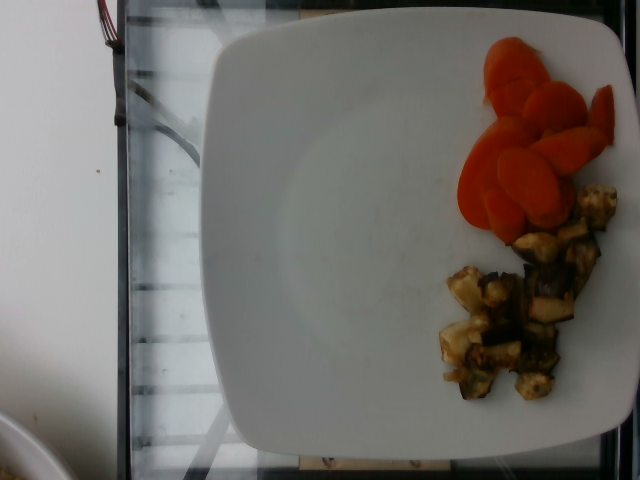

,idx,image,cal_true,cal_resnet,cal_vlm,protein_true,protein_resnet,protein_vlm,carb_true,carb_resnet,carb_vlm,fat_true,fat_resnet,fat_vlm
0,51,dish_1563308353_rgb.png,51.465488,44.591812,101.0,1.31949,1.615154,2.74,10.880392,9.462861,12.7,1.002588,0.997527,5.46



--- idx=250  dish_1558635618_rgb.png ---


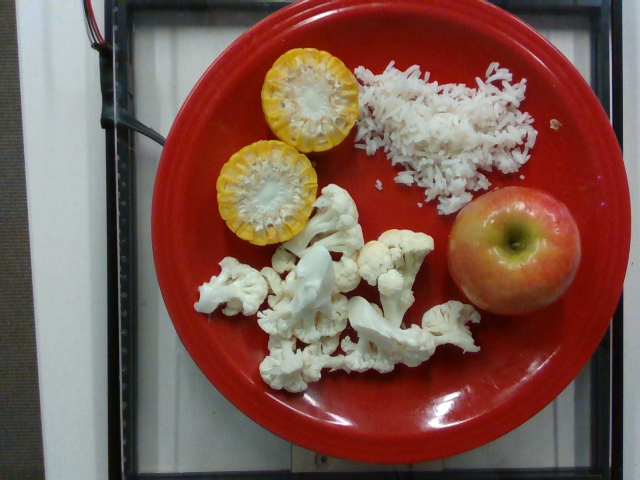

,idx,image,cal_true,cal_resnet,cal_vlm,protein_true,protein_resnet,protein_vlm,carb_true,carb_resnet,carb_vlm,fat_true,fat_resnet,fat_vlm
1,250,dish_1558635618_rgb.png,220.253998,237.618805,211.0,5.606,8.277282,6.14,49.700001,46.914146,48.12,2.439,4.832887,2.74



--- idx=253  dish_1562686548_rgb.png ---


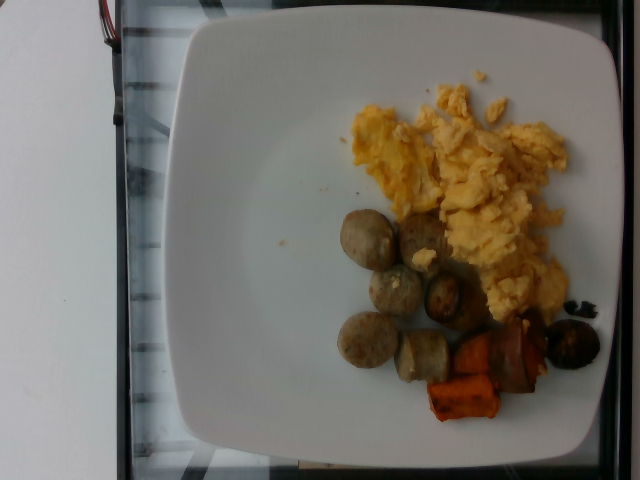

,idx,image,cal_true,cal_resnet,cal_vlm,protein_true,protein_resnet,protein_vlm,carb_true,carb_resnet,carb_vlm,fat_true,fat_resnet,fat_vlm
2,253,dish_1562686548_rgb.png,413.493988,167.768204,441.0,27.464001,8.8584,24.56,20.892,8.859124,24.56,23.967999,9.030275,29.0



--- idx=377  dish_1562777566_rgb.png ---


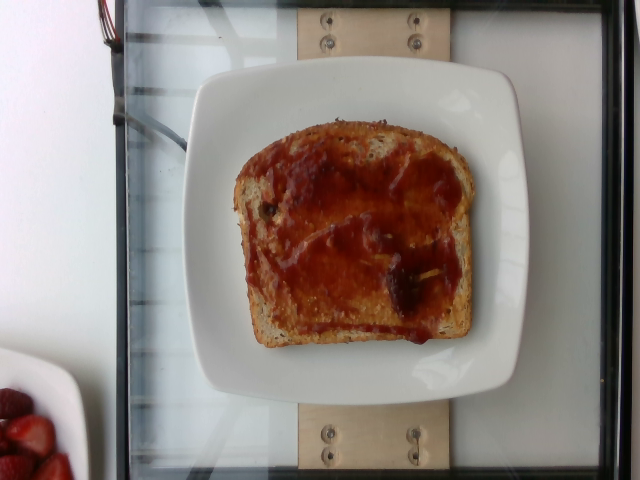

,idx,image,cal_true,cal_resnet,cal_vlm,protein_true,protein_resnet,protein_vlm,carb_true,carb_resnet,carb_vlm,fat_true,fat_resnet,fat_vlm
3,377,dish_1562777566_rgb.png,263.003998,229.279633,251.0,10.92,13.124907,5.16,46.619999,16.537033,40.16,3.528,13.938233,8.16



--- idx=445  dish_1563218959_rgb.png ---


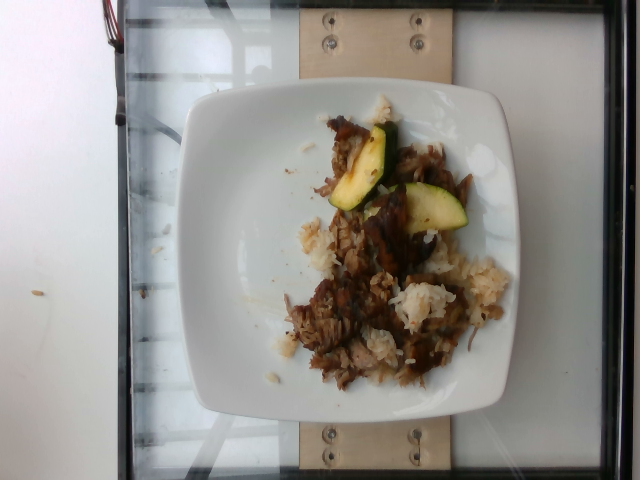

,idx,image,cal_true,cal_resnet,cal_vlm,protein_true,protein_resnet,protein_vlm,carb_true,carb_resnet,carb_vlm,fat_true,fat_resnet,fat_vlm
4,445,dish_1563218959_rgb.png,267.939667,234.983597,311.0,26.745079,34.652939,24.16,4.849844,6.38063,17.4,14.862059,10.21751,16.64



Summary (all preview rows):


,idx,image,cal_true,cal_resnet,cal_vlm,protein_true,protein_resnet,protein_vlm,carb_true,carb_resnet,carb_vlm,fat_true,fat_resnet,fat_vlm
0,51,dish_1563308353_rgb.png,51.465488,44.591812,101.0,1.319490,1.615154,2.74,10.880392,9.462861,12.70,1.002588,0.997527,5.46
1,250,dish_1558635618_rgb.png,220.253998,237.618805,211.0,5.606000,8.277282,6.14,49.700001,46.914146,48.12,2.439000,4.832887,2.74
2,253,dish_1562686548_rgb.png,413.493988,167.768204,441.0,27.464001,8.858400,24.56,20.892000,8.859124,24.56,23.967999,9.030275,29.00
3,377,dish_1562777566_rgb.png,263.003998,229.279633,251.0,10.920000,13.124907,5.16,46.619999,16.537033,40.16,3.528000,13.938233,8.16
4,445,dish_1563218959_rgb.png,267.939667,234.983597,311.0,26.745079,34.652939,24.16,4.849844,6.380630,17.40,14.862059,10.217510,16.64


In [9]:
# Same test indices for both models (only rows in the VLM eval slice).
from IPython.display import Image as IPyImage, display

PREVIEW_N = int(os.environ.get("COMPARE_PREVIEW_SAMPLES", "5"))
PREVIEW_IMG_WIDTH = int(os.environ.get("COMPARE_PREVIEW_IMG_WIDTH", "420"))

n_eval = len(eval_paths)
k = min(PREVIEW_N, n_eval)
rng = np.random.default_rng(42)
idx_sample = np.sort(rng.choice(n_eval, size=k, replace=False))

short = ["cal", "protein", "carb", "fat"]
rows = []
for i in idx_sample:
    p = Path(paths[i])
    row = {"idx": int(i), "image": p.name}
    for j, base in enumerate(short):
        row[f"{base}_true"] = float(y_true[i, j])
        row[f"{base}_resnet"] = float(y_pred_resnet[i, j])
        vv = y_pred_vlm[i, j]
        row[f"{base}_vlm"] = float(vv) if np.isfinite(vv) else np.nan
    rows.append(row)

preview_df = pd.DataFrame(rows)
print(f"Showing {len(preview_df)} / {n_eval} evaluated test rows (seed=42).")

for i in idx_sample:
    p = paths[i]
    print(f"\n--- idx={i}  {Path(p).name} ---")
    display(IPyImage(filename=p, width=PREVIEW_IMG_WIDTH))
    display(preview_df.loc[preview_df["idx"] == i])

print("\nSummary (all preview rows):")
display(preview_df)